# Training

In [ ]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

2026-01-21 16:06:22.740941: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/mnt/Research/Rheed-FOLO/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

In [3]:
# Generate Gaussian Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    label = np.zeros(shape=(LABEL_Y, LABEL_X, 1))
    params = []

    num_gaussians = np.random.randint(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS)
    for gaussian in range(num_gaussians):

        # Randomize params
        center_x = np.random.randint(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = np.random.randint(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
        std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
        theta = np.random.randint(low=MIN_THETA, high=MAX_THETA)
        
        intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)
        
        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta)

        # Add Gaussian to img
        img += intensity * gaussian
        # img += gaussian
        
        label_x = center_x // SCALE_FACTOR
        label_y = center_y // SCALE_FACTOR

        label[label_y, label_x] = 1

    # Convert to 8 bit int
    img = (img * 255).astype(np.uint8)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        print(f"[Target Gaussians #]: {str(num_gaussians)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (img, label, params)

def gaussian_gen(center_x: int, center_y: int, std_x: int, std_y: int, theta: float) -> np.ndarray:
    
    X = np.arange(0, IMAGE_X, 1)
    Y = np.arange(0, IMAGE_Y, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.pow(np.cos(theta),2)
    sin_theta_sqrd = np.pow(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.pow(std_x, 2)
    std_y_sqrd = np.pow(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, label: np.ndarray, params: list = None, threshold: int = THRESHOLD) -> None:
    
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Coords of Gaussians:
    for x in range(LABEL_X):
        for y in range(LABEL_Y):
            if label[y, x,] >= threshold:
                
                top_left = (x * SCALE_FACTOR - GAUSSIAN_X // 2, y * SCALE_FACTOR - GAUSSIAN_Y // 2)
                bottom_right = (x * SCALE_FACTOR + GAUSSIAN_X // 2, y * SCALE_FACTOR + GAUSSIAN_Y // 2)
                color = (0, 200, 200)
                thickness = 2
                
                cv2.rectangle(rgb_image, top_left, bottom_right, color, thickness)

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )
    
    plt.imshow(rgb_image)

def img_visualization_two(img: np.ndarray, label: np.ndarray, params: list = None) -> None:
    
    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='gray')

[(c_x, c_y)]: (193, 39 ) [(s_x, s_y)]: (8  , 10 ) [Theta]: 0.00 [I]: 0.38 
[(c_x, c_y)]: (77 , 45 ) [(s_x, s_y)]: (5  , 7  ) [Theta]: 0.00 [I]: 0.54 


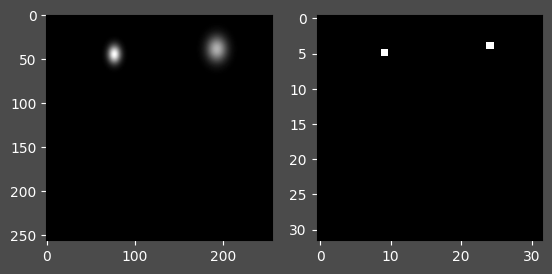

In [4]:
# Test Generate Functions #

img, label, params = img_gen()
img_visualization_two(img, label, params)

In [5]:
# Generate Training Dataset #
SAMPLE_COUNT = 1000

img_arr = []
label_arr = []

def process_image():
    img, label, _ = img_gen()
    return img, label

img_arr = []
label_arr = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLE_COUNT)]
    for future in tqdm(as_completed(futures), total=SAMPLE_COUNT):
        img, label = future.result()
        img_arr.append(np.round(img.astype(np.float32) / (np.max(img.astype(np.float32)) + 1) * 256) / 256) # Normalize values to [0, 1)
        label_arr.append(label)

img_arr = np.array(img_arr).astype(np.float32)
label_arr = np.array(label_arr).astype(np.float32)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 1000/1000 [00:02<00:00, 370.72it/s]


[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


In [6]:
# Convert Data to tf DataSet #
BATCH_SIZE = 50

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

I0000 00:00:1769040398.930026   10973 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4810 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


In [7]:
# Model Architecture # 

input_layer = Input(shape=(IMAGE_X, IMAGE_Y, 1), name='InputLayer')

# x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(input_layer)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
# x = ReLU()(x)
x = MaxPool2D(pool_size=2)(input_layer)

x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2)(x)

x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2)(x)

x_prob = Conv2D(1, kernel_size=3, padding='same', name='x_prob', activation='sigmoid', kernel_initializer='lecun_uniform')(x)

baby_yolo = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo')

In [8]:
# Tensorflow Functions #

def loss_p(y_true, y_pred):
    loss = tf.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss)


In [9]:
# Training Loop #
NUM_EPOCHS = 100

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=NUM_EPOCHS,
    decay_rate=0.9)

adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
baby_yolo.compile(optimizer=adam_optimizer, loss=loss_p, run_eagerly=True)

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    
    for batch in tqdm(dataset):
        with tf.GradientTape() as tape:
            prediction = baby_yolo(batch[0])
            loss = loss_p(batch[1], prediction)  # Compute the loss
        grads = tape.gradient(loss, baby_yolo.trainable_variables)
        adam_optimizer.apply_gradients(zip(grads, baby_yolo.trainable_variables))
        running_loss += loss.numpy()
        
    average_loss = running_loss / len(dataset)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {average_loss}")


100%|██████████| 20/20 [00:01<00:00, 10.92it/s]


Epoch [1/100], Loss: 11724.548828125


100%|██████████| 20/20 [00:00<00:00, 33.20it/s]


Epoch [2/100], Loss: 921.64208984375


100%|██████████| 20/20 [00:00<00:00, 32.36it/s]


...

Epoch [98/100], Loss: 120.91151428222656


100%|██████████| 20/20 [00:00<00:00, 33.31it/s]


Epoch [99/100], Loss: 120.16886138916016


100%|██████████| 20/20 [00:00<00:00, 33.56it/s]

Epoch [100/100], Loss: 120.17236328125


In [10]:
# Model Summary #

baby_yolo.summary()

Model: "baby_yolo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_prob (Conv2D)                 │ (None, 32, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,876 (30.77 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,251 (20.52 KB)

In [11]:
# Create Validation Dataset #
VAL_COUNT = 100

img_arr_val = []
label_arr_val = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        # img_arr.append(img / (np.max(img) + 1)) # Normalize values to [0, 1)
        img_arr_val.append(np.round(img.astype(np.float32) / (np.max(img.astype(np.float32)) + 1) * 256) / 256) # Normalize values to [0, 1)
        label_arr_val.append(label)

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)



print(f'[Validation Shape]: {img_arr_val.shape}')


100%|██████████| 100/100 [00:00<00:00, 401.42it/s]

[Validation Shape]: (100, 256, 256, 1)


0.61420536


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


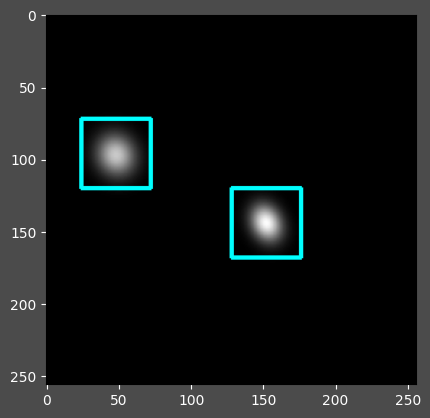

In [18]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

predictions_tf = baby_yolo(img_arr_val)
print(np.max(predictions_tf[index]))
img_visualization_one(img_arr_val[index], predictions_tf[index])

In [ ]:
# SAVE MODEL #

baby_yolo.save("FOLO_Gen_256.keras")

# HLS4ML

In [20]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model

config = config_from_keras_model(baby_yolo, granularity='name', backend='Vitis')
config['Model']['Strategy'] = 'Latency'
config['Model']['ReuseFactor'] = 1
# config['Model']['Precision'] = 'ap_fixed<16,6>'
hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo,
    hls_config=config,
    output_dir='folo_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    default_precision='fixed<32,16>',
    part='xcku035-fbva676-2-e',
    project_name='folo'
)

In [21]:
# Compile Model #

hls_model.compile()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


0.72753906


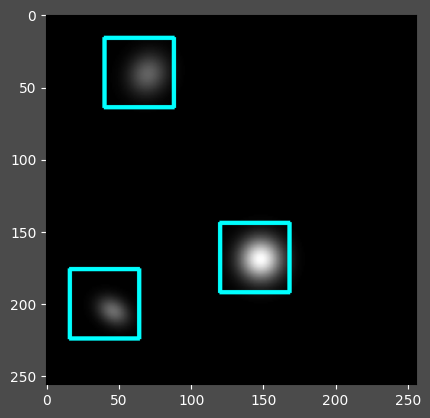

In [22]:
# Visual Validation #

index = np.random.randint(low=0, high=VAL_COUNT)

predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)
print(np.max(predictions_hls4ml[index]))
img_visualization_one(img_arr_val[index], predictions_hls4ml[index])

In [ ]:
# Build Model #
# vitis_hls build_prj.tcl

# hls_model.build(csim=False)

In [27]:
# View Report #
hls4ml.report.read_vivado_report('folo_hls4ml')

Found 1 solution(s) in folo_hls4ml/folo_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'folo'
* Date:           Wed Jan 21 16:18:17 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        folo_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: kintexu
* Target device:  xcku035-fbva676-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.847 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+--------+--------+----------+
    |  Latency (cycles) |  Latency (absolute) |     Interval    | Pipeline |
    |   min   |   max   |    min   |    max   |   min  |   max  |   Type   |
    +---------+---------+----------+--